# Predicciones
Dentro de este archivo y a lo largo del mismo, se exploraran diversas tecnicas y algoritmos de prediccion con el fin de poder estimar valores basados en nuestros datos actuales, para ello se intentara resolver las siguientes preguntas:

1. ¿Es posible predecir la popularidad de una canción usando únicamente sus características musicales?

2. ¿Qué variables tienen mayor importancia en el modelo predictivo?

3. ¿Qué algoritmo ofrece mejor desempeño para estimar la popularidad?

4. ¿Se puede clasificar una canción como "éxito" o "no éxito" utilizando aprendizaje automático?

5. ¿Puede un modelo de machine learning predecir el éxito comercial de una canción antes de su lanzamiento?

<hr />


In [2]:
import pandas as pd

caracteristicas = pd.read_csv('../dataset/main_dataset.csv', usecols=['popularity','danceability','energy','key','loudness','mode','acousticness','instrumentalness','valence','tempo','duration_ms','time_signature', 'album_type'])
caracteristicas.head()

,popularity,album_type,danceability,energy,key,loudness,mode,acousticness,instrumentalness,valence,tempo,duration_ms,time_signature
0,0,single,0.611,0.614,5.0,-8.815,0.0,0.0169,0.000794,0.520,128.050,195000.0,4.0
1,33,album,0.638,0.781,4.0,-6.848,0.0,0.0118,0.009530,0.250,122.985,194641.0,4.0
2,52,single,0.560,0.810,0.0,-8.029,0.0,0.0071,0.000008,0.247,170.044,217573.0,4.0
3,0,single,0.525,0.699,9.0,-4.571,1.0,0.0178,0.000088,0.199,92.011,443478.0,4.0
4,0,single,0.367,0.771,9.0,-5.863,1.0,0.3650,0.000001,0.163,115.917,225862.0,4.0


## Transformaciones

Con el fin de realizar mejores predicciones, se realizara una serie de diferentes transformaciones a las variables del dataset con el fin de simplificar o generalizar algunas caracteristicas de las canciones.

### Cambios
1. **popularity**
    * Primero se observaran las popularidades de las diversas canciones y con respecto, a ello. se realizara el tratamiento de outliners. Asi mismo, se categorizara la variable con el fin de que sea mas sencillo realizar una prediccion sobre ella, aquellas canciones por encima de un 60 de popularidad (popularity >= 60) se denominara como cancion popular o exito, en caso contrario (popularity < 60) se le catalogara como fracaso.

2. **acousticness**
    * Para esta variable, tambien se realizara una categorizacion puesto que al ser una probabilidad, los diversos valores solo meteran ruido en la informacion. Por esto mismo, a aquellas canciones que un acousticness mayor a 60 (acousticness >= 60) se les asignara el valor 1 (acustica), de otra forma (acousticness < 60), se les catalogara como 0 (electrica/sintetica)

3. **album_type**
    * Se categorizara la variable como 0, 1 o 2, con el fin de usar numeros, 0 es album, 1 es single y 2 es compilacion

4. **instrumentalness**
    * Para aquellos valores mayores a 0.6 (instrumentalness >= 0.6) se tomaran como 1 (canciones puramente intrsumentales), de otra forma, se asignara 0 (canciones no instrumentales)

5. **speechiness**
    * 


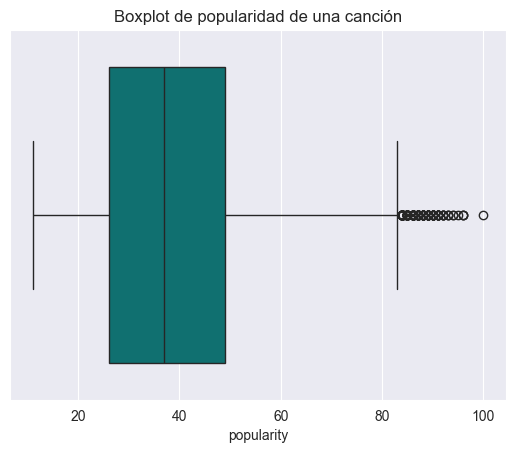

=============== VALORES >= 45 ===============
Cantidad de valores mayores o iguales a 45: 66799
Porcentaje de valores mayores o iguales a 45: 33.38%


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


caracteristicas = caracteristicas[caracteristicas['popularity'] > 10]


sns.set_style('darkgrid')
sns.boxplot(x=caracteristicas['popularity'], color='teal')
plt.title('Boxplot de popularidad de una canción')
plt.show()


es_exito = caracteristicas['popularity'] >= 45

resumen5 = {
    'num': es_exito.sum(),
    'prc': round(es_exito.mean() * 100, 2)
}

print('=' * 15, 'VALORES >= 45', '=' * 15)
print(f'Cantidad de valores mayores o iguales a 45: {resumen5["num"]}')
print(f'Porcentaje de valores mayores o iguales a 45: {resumen5["prc"]}%')


caracteristicas['popularity'] = es_exito.astype(int)


Se eliminaron del conjunto de datos aquellas canciones con una popularidad inferior a 10 puntos. Esta decisión se fundamenta en que una baja popularidad no necesariamente refleja una falta de calidad o de características asociadas al éxito comercial. En muchos casos, canciones con atributos similares a los de temas exitosos pueden no alcanzar una alta popularidad debido a factores externos, como estrategias de promoción, exposición mediática, tendencias del mercado o elementos aleatorios difíciles de cuantificar.

Con base en el análisis de la grafica del conjunto de datos, se estableció un umbral de popularidad de 45 puntos para clasificar una canción como un éxito. Inicialmente, se consideró utilizar un umbral de 60 puntos; sin embargo, esta elección generaba una distribución altamente desbalanceada, ya que únicamente alrededor del 7% de las observaciones eran clasificadas como éxitos.

Al reducir el umbral a 45 puntos, la proporción de canciones catalogadas como éxitos aumenta aproximadamente al 33% del conjunto de datos. Aunque la distribución resultante continúa presentando cierto grado de desbalance, este nivel es considerablemente más manejable para el entrenamiento y evaluación de modelos de aprendizaje automático, permitiendo obtener resultados más robustos y representativos.

### Acousticness)


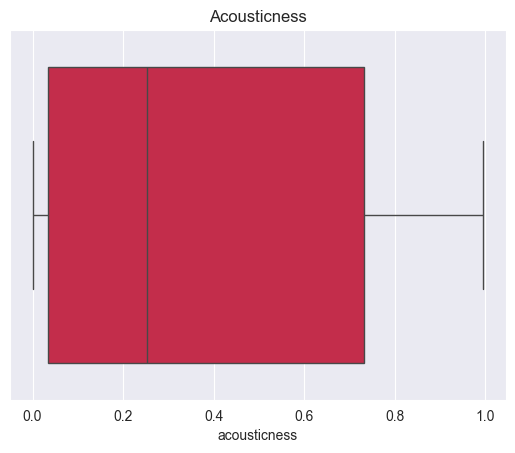

=============== VALORES >= 0.5 ===============
Cantidad de valores mayores o iguales a 0.5: 72621
Porcentaje de valores mayores o iguales a 0.5: 36.28%


In [4]:
acustica = caracteristicas['acousticness']


sns.boxplot(x=acustica, color='crimson')
plt.title('Acousticness')
plt.show()

es_acustica = acustica >= 0.5

resumenAcous = {
    'num': es_acustica.sum(),
    'prc': round(es_acustica.mean() * 100, 2)
}

print('=' * 15, 'VALORES >= 0.5', '=' * 15)
print(f'Cantidad de valores mayores o iguales a 0.5: {resumenAcous["num"]}')
print(f'Porcentaje de valores mayores o iguales a 0.5: {resumenAcous["prc"]}%')

caracteristicas['acousticness'] = es_acustica.astype(int)

Para la variable acousticness, se estableció un umbral de 0.5 en una escala de 0 a 1. De esta forma, todos los valores mayores o iguales a 0.5 fueron clasificados como 1. Dado que esta variable representa la probabilidad de que una canción sea acústica, se consideró que aquellas con una probabilidad igual o superior al 50 % podían clasificarse como acústicas. Esta transformación permitió reducir la variabilidad de los datos y generar categorías más manejables para los modelos predictivos.


### Tipo de album

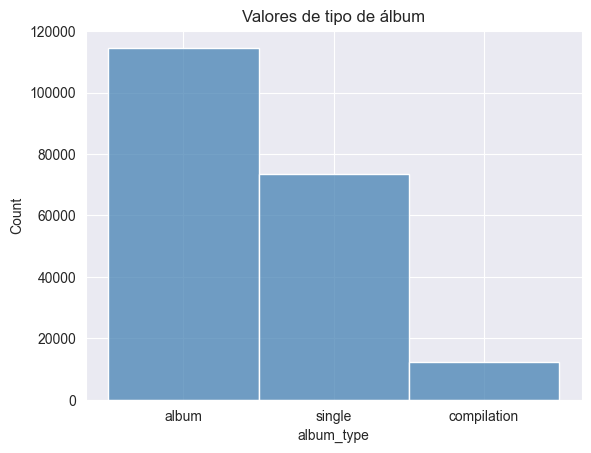

Valores originales: <StringArray>
['album', 'single', 'compilation']
Length: 3, dtype: str
Valores codificados: [0 1 2]


In [5]:
sns.histplot(caracteristicas['album_type'], color='steelblue')
plt.title('Valores de tipo de álbum')
plt.show()

valores = {
    'album': 0,
    'single': 1,
    'compilation': 2
}

print('Valores originales:', caracteristicas['album_type'].unique())

caracteristicas['album_type'] = caracteristicas['album_type'].map(valores).astype('int64')

print('Valores codificados:', caracteristicas['album_type'].unique())

Para la variable album_type, únicamente se realizó una transformación de los valores categóricos de tipo cadena de texto a valores enteros. Esta decisión se tomó para facilitar las operaciones computacionales y evitar el incremento de la dimensionalidad del conjunto de datos, problema que suele presentarse al aplicar técnicas como One-Hot Encoding.

### instrumentalness)

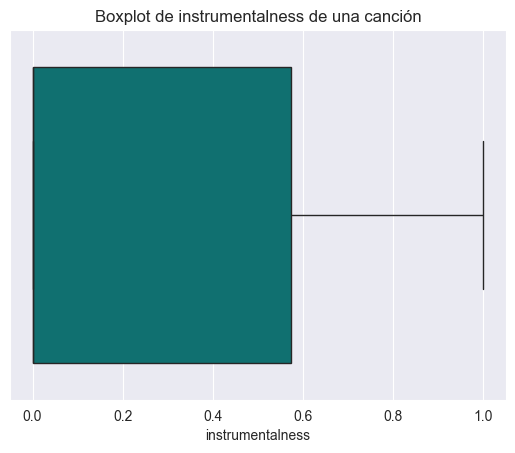

=============== VALORES >= 0.5 ===============
Cantidad de valores mayores o iguales a 0.5: 52294
Porcentaje de valores mayores o iguales a 0.5: 26.13%


In [6]:
instrumentales = caracteristicas['instrumentalness']


sns.boxplot(x=instrumentales, color='teal')
plt.title('Boxplot de instrumentalness de una canción')
plt.show()

es_instrumental = instrumentales >= 0.5

resumen5 = {
    'num': es_instrumental.sum(),
    'prc': round(es_instrumental.mean() * 100, 2)
}

print('=' * 15, 'VALORES >= 0.5', '=' * 15)
print(f'Cantidad de valores mayores o iguales a 0.5: {resumen5["num"]}')
print(f'Porcentaje de valores mayores o iguales a 0.5: {resumen5["prc"]}%')


caracteristicas['instrumentalness'] = es_instrumental.astype(int)


En el caso de instrumentalness, las canciones cuya probabilidad de ser instrumentales era superior al 50 % fueron clasificadas como canciones instrumentales. Esta discretización permitió simplificar la interpretación de la variable durante el proceso de modelado.

### Valores numericos a estandarizar
Para las variables loudness, valence, tempo, danceability, energy y duration, e estandarizaran, sin embargo, para estandarizar correctamente, primero se dividiran los datos entre el conjunto de entrenamiento y el conjunto de prueba. Asi mismo, se separara la variable a predecir del dataset

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

caracteristicas.drop(columns=['key','time_signature','mode'], inplace = True)

y = caracteristicas['popularity']
X = caracteristicas.drop(columns=['popularity'])

x_train, x_test, y_train, y_test = train_test_split(X,y, train_size=0.8, stratify=y, random_state=777)

columnas_a_estandarizar = [
    'loudness',
    'valence',
    'tempo',
    'danceability',
    'energy',
    'duration_ms'
]

scaler = StandardScaler()


x_train[columnas_a_estandarizar] = scaler.fit_transform(
    x_train[columnas_a_estandarizar]
)


x_test[columnas_a_estandarizar] = scaler.transform(
    x_test[columnas_a_estandarizar]
)

x_train.info()




<class 'pandas.DataFrame'>
Index: 160115 entries, 3699 to 262802
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   album_type        160115 non-null  int64  
 1   danceability      160115 non-null  float64
 2   energy            160115 non-null  float64
 3   loudness          160115 non-null  float64
 4   acousticness      160115 non-null  int64  
 5   instrumentalness  160115 non-null  int64  
 6   valence           160115 non-null  float64
 7   tempo             160115 non-null  float64
 8   duration_ms       160115 non-null  float64
dtypes: float64(6), int64(3)
memory usage: 12.2 MB


## Predicciones
Se utilizarán tres modelos diferentes para predecir si una canción puede considerarse exitosa o no. A partir de los resultados obtenidos, será posible responder las preguntas de investigación planteadas al inicio de este documento y evaluar la capacidad predictiva de las características analizadas.

### Regresion logistica

In [8]:
from sklearn.metrics import accuracy_score, matthews_corrcoef
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    class_weight='balanced',
    random_state=777,
    max_iter=2000,
)
lr.fit(x_train, y_train)
y_pred_lr = lr.predict(x_test)


print("Accuracy:", round(accuracy_score(y_test, y_pred_lr),2))
print("MCC:", round(matthews_corrcoef(y_test, y_pred_lr),2))


Accuracy: 0.57
MCC: 0.19


lol

### Random Forest

In [9]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=700,
    max_depth=20,
    class_weight='balanced',
    min_samples_split=15,
    random_state=777,
    n_jobs=-1
)

rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred_rf),2))
print("MCC:", round(matthews_corrcoef(y_test, y_pred_rf),2))


importancias_rf = pd.DataFrame({
    'Variable': x_train.columns,
    'Importancia': rf.feature_importances_
})
importancias_rf = importancias_rf.sort_values(
    by='Importancia',
    ascending=False
)
print(importancias_rf)





Accuracy: 0.63
MCC: 0.25
           Variable  Importancia
3          loudness     0.181031
8       duration_ms     0.165043
2            energy     0.146172
1      danceability     0.140683
6           valence     0.133295
7             tempo     0.128512
5  instrumentalness     0.062735
0        album_type     0.029797
4      acousticness     0.012732


### XGboost

In [10]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=700,
    learning_rate=0.05,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=7,
    eval_metric='logloss'
)

xgb.fit(x_train, y_train)
y_pred_xgb = xgb.predict(x_test)
print("Accuracy:", round(accuracy_score(y_test, y_pred_xgb),2))
print("MCC:", round(matthews_corrcoef(y_test, y_pred_xgb),2))


importancias_xgb = pd.DataFrame({
    'Variable': x_train.columns,
    'Importancia': xgb.feature_importances_
})

importancias_xgb = importancias_xgb.sort_values(
    by='Importancia',
    ascending=False
)

print(importancias_xgb)

Accuracy: 0.68
MCC: 0.2
           Variable  Importancia
5  instrumentalness     0.410530
0        album_type     0.090479
4      acousticness     0.084925
3          loudness     0.076128
8       duration_ms     0.070539
1      danceability     0.068544
2            energy     0.068290
6           valence     0.066086
7             tempo     0.064479


In [11]:
y_pred_xgb = xgb.predict(x_test)
resultados = x_test.copy()
resultados['y_real'] = y_test.values
resultados['y_pred'] = y_pred_xgb


resultados['correcto'] = resultados['y_real'] == resultados['y_pred']
resumen = (
    resultados
    .groupby('album_type')['correcto']
    .agg(
        total='count',
        correctos='sum'
    )
)

resumen['incorrectos'] = resumen['total'] - resumen['correctos']
resumen['prop_correctos'] = resumen['correctos'] / resumen['total']
resumen['prop_incorrectos'] = resumen['incorrectos'] / resumen['total']

print(resumen)


            total  correctos  incorrectos  prop_correctos  prop_incorrectos
album_type                                                                 
0           23011      15607         7404        0.678241          0.321759
1           14700       9825         4875        0.668367          0.331633
2            2318       1744          574        0.752373          0.247627


### Analisis de modelos predictivos

Para los tres modelos predictivos evaluados se realizaron múltiples experimentos mediante el ajuste de hiperparámetros. Tras diversas pruebas, se seleccionaron las configuraciones que ofrecieron el mejor desempeño dentro de los escenarios analizados.

La evaluación de los modelos se llevó a cabo mediante dos métricas principales: Accuracy Score y Matthews Correlation Coefficient (MCC). El Accuracy mide la proporción de predicciones correctas realizadas por el modelo, tomando valores entre 0 y 1. Por su parte, el MCC considera los cuatro posibles resultados de una matriz de confusión (verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos), generando valores entre -1 y 1, donde -1 representa una clasificación completamente incorrecta, 0 indica un comportamiento equivalente al azar y 1 corresponde a una clasificación perfecta.

Aunque el Accuracy proporciona una medida general del porcentaje de aciertos, se consideró especialmente relevante el MCC debido al desbalance presente en las clases del conjunto de datos. De esta forma, es posible determinar si el modelo realmente aprendió patrones útiles o si simplemente favorece la clase mayoritaria, obteniendo un Accuracy aparentemente elevado sin una capacidad predictiva real.

* Regresión Logística

    * La regresión logística obtuvo un Accuracy de 0.57, lo que indica que aproximadamente el 57 % de las muestras del conjunto de prueba fueron clasificadas correctamente. Sin embargo, esto también implica que una proporción considerable de observaciones fue clasificada de forma incorrecta. Su valor de MCC fue cercano a 0.19, lo que sugiere que el modelo logró capturar ciertos patrones en los datos, aunque su capacidad predictiva sigue siendo limitada.

* Random Forest

    * El modelo Random Forest presentó un desempeño superior al de la regresión logística, alcanzando un Accuracy de 0.68. Esto significa que más de dos terceras partes de las muestras fueron clasificadas correctamente. No obstante, su MCC fue de aproximadamente 0.20, valor que indica una mejora modesta respecto al modelo anterior y evidencia que aún existen dificultades para distinguir adecuadamente entre las clases.

    * El análisis de importancia de variables mostró que loudness, duration_ms y energy fueron las características con mayor influencia en las predicciones. Este resultado sugiere que dichas variables contienen información relevante para diferenciar entre canciones exitosas y no exitosas dentro del conjunto de datos analizado.

* XGBoost

    * El modelo XGBoost obtuvo resultados prácticamente idénticos a los de Random Forest, tanto en Accuracy como en MCC. Aunque ambos algoritmos se basan en árboles de decisión, difieren en la forma en que construyen y combinan sus modelos, por lo que resulta interesante que hayan alcanzado desempeños tan similares.

    * En cuanto a la importancia de variables, XGBoost identificó a album_type como la característica más relevante. A partir de este hallazgo, se analizó la proporción de clasificaciones correctas para cada categoría de esta variable. Se observó que la categoría compilation presentó la mayor tasa de aciertos, con aproximadamente un 75 % de canciones clasificadas correctamente.

    * Este resultado podría indicar una relación entre la aparición de una canción en un álbum de tipo compilación y su nivel de éxito. Una posible explicación es que las canciones incluidas en compilaciones suelen haber alcanzado previamente cierta popularidad o reconocimiento comercial, lo que las convierte en candidatas para ser relanzadas dentro de este tipo de producciones.

Por lo tanto, se puede concluir que las características musicales poseen cierta capacidad para predecir el éxito de una canción; sin embargo, dicha capacidad es limitada y moderada. Los resultados obtenidos sugieren que estas variables, por sí solas, no son suficientes para explicar completamente el éxito comercial de una pieza musical.

Esta situación puede atribuirse a diversos factores externos que no fueron considerados en el conjunto de datos. Entre ellos destacan la influencia de las redes sociales, las campañas de marketing, la popularidad previa de los artistas, las recomendaciones de las plataformas de streaming y los fenómenos virales que se generan en medios digitales.

En la actualidad, plataformas como TikTok, Instagram Reels y YouTube Shorts tienen la capacidad de impulsar significativamente la popularidad de una canción en periodos muy cortos de tiempo. Como consecuencia, algunas canciones pueden alcanzar niveles elevados de éxito comercial debido a su difusión viral, independientemente de que sus características musicales sean similares a las de otras canciones con menor impacto. Esto sugiere que el éxito musical es un fenómeno complejo que depende tanto de factores musicales como de elementos sociales, culturales y tecnológicos.

<hr />

## Cambio de enfoque

Despues de darnos cuenta que no se puede predecir el exito de una cancion meramente por los atributos musicales de la misma, se optara por tomar en cuenta datos agenos a la pieza, como informacion de sus respectivos autores o playlists en las que se encuentran

Esta vez, se tomara informacion de playlists en las que se encuentra una cancion e informacion de su respectivo artista


In [12]:
canciones = pd.read_csv('../Dataset/main_dataset.csv', usecols=['track_uri','name','popularity','playlist_uris','artists_names','artists_uris','artists_popularities','artists_genres','artists_followers'])
artistas = pd.read_csv('../Dataset/artists.csv', usecols=['artist_uri','artist_popularity','artist_genres','artist_followers'])
playlists = pd.read_csv('../Dataset/final_playlists.csv', usecols=['uri','name','author','n_tracks','playlist_followers'])

### Caracteristicas a considerar
* Variable a predecir -> popularity, categorizada de la misma forma que en la seccion anterior
* Variables predictoras
    1. Numero_de_artistas_involucrados 
    2. Popularidad media de los artistas 
    3. numero medio de generos por artista 
    4. Numero medio de seguidores por artistas 
    5. Numero medio de popularidad de playlists
    6. Numero medio de canciones por playlists 
    7. Numero medio de seguidores por playlists

## Caracteristicas de una cancion

In [ ]:
import ast
columnas_lista = [
    'playlist_uris',
    'artists_uris',
    'artists_popularities',
    'artists_genres',
    'artists_followers'
]

for col in columnas_lista:
    canciones[col] = canciones[col].apply(
        lambda x: ast.literal_eval(x) if pd.notna(x) else []
    )

    
features = pd.DataFrame()
features['track_uri'] = canciones['track_uri']
features['Popularidad_cancion'] = canciones['popularity']
features['Nombre'] = canciones['name']



,Popularidad_cancion,Numero_de_artistas_involucrados,Popularidad_media_artistas,Numero_medio_generos_por_artista,Seguidores_medios_artistas,Numero_medio_canciones_playlists,Seguidores_medios_playlists
0,0,1,9.0,0.0,765.0,241.0,890.0
1,0,2,62.0,2.5,711030.5,241.0,890.0
2,1,1,65.0,5.0,1544981.0,241.0,890.0
3,0,1,32.0,2.0,18241.0,241.0,890.0
4,0,2,34.5,1.0,11940.0,241.0,890.0


### Caracteristicas de los artistas

In [ ]:

features['Numero_de_artistas_involucrados'] = (
    canciones['artists_uris'].apply(len)
)


features['Popularidad_media_artistas'] = (
    canciones['artists_popularities']
    .apply(lambda x: np.mean(x) if len(x) > 0 else np.nan)
)


features['Numero_medio_generos_por_artista'] = (
    canciones['artists_genres']
    .apply(
        lambda lista_generos:
            np.mean([len(g) for g in lista_generos])
            if len(lista_generos) > 0 else np.nan
    )
)

features['Seguidores_medios_artistas'] = (
    canciones['artists_followers']
    .apply(lambda x: np.mean(x) if len(x) > 0 else np.nan)
)

### Caracteristicas de las playlists

In [ ]:
playlist_song = canciones[['track_uri', 'playlist_uris']].explode('playlist_uris')

playlist_song = playlist_song.merge(
    playlists,
    left_on='playlist_uris',
    right_on='uri',
    how='left'
)

playlist_features = (
    playlist_song
    .groupby('track_uri')
    .agg(
        Numero_medio_canciones_playlists=('n_tracks', 'mean'),
        Seguidores_medios_playlists=('playlist_followers', 'mean')
    )
    .reset_index()
)

resultado = features.merge(
    playlist_features,
    on='track_uri',
    how='left'
)

es_exito = resultado['Popularidad_cancion'] >= 45
resultado['Popularidad_cancion'] = es_exito.astype(int)
resultado.drop(columns=['track_uri','Nombre'], inplace=True)


resultado.head()


## Creacion de modelos predicticos
Similar a la etapa anterior, se utilizaran 3 modelos predictivos diferentes, con el fin de no tener una sola respuesta, posteriormente se analizaran sus resultados, ajustaran hiperparametros y finalmente, se eligira el modelo que rpesenta las mejores predicciones sobre nuestros datos.
Una vez mas, se volveran a utilizar 2 metricas clave, el accuracy y el MCC

In [14]:
y2 = resultado['Popularidad_cancion']
X2 = resultado.drop(columns=['Popularidad_cancion'])

x_train2, x_test2, y_train2, y_test2 = train_test_split(X2,y2, train_size=0.7, stratify=y2, random_state=777)

rf2 = RandomForestClassifier(
    n_estimators=700,
    max_depth=20,
    class_weight='balanced',
    min_samples_split=15,
    random_state=777,
    n_jobs=-1
)

rf2.fit(x_train2, y_train2)
y_pred_rf2 = rf2.predict(x_test2)

print("Accuracy:", round(accuracy_score(y_test2, y_pred_rf2),2))
print("MCC:", round(matthews_corrcoef(y_test2, y_pred_rf2),2))


importancias_rf2 = pd.DataFrame({
    'Variable': x_train2.columns,
    'Importancia': rf2.feature_importances_
})
importancias_rf2 = importancias_rf2.sort_values(
    by='Importancia',
    ascending=False
)
print(importancias_rf2)


Accuracy: 0.8
MCC: 0.55
                           Variable  Importancia
1        Popularidad_media_artistas     0.397844
3        Seguidores_medios_artistas     0.227731
5       Seguidores_medios_playlists     0.186096
4  Numero_medio_canciones_playlists     0.119895
2  Numero_medio_generos_por_artista     0.057736
0   Numero_de_artistas_involucrados     0.010699


In [16]:
from xgboost import XGBClassifier

xgb2 = XGBClassifier(
    n_estimators=700,
    learning_rate=0.05,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=7,
    eval_metric='logloss'
)

xgb2.fit(x_train2, y_train2)
y_pred_xgb2 = xgb2.predict(x_test2)
print("Accuracy:", round(accuracy_score(y_test2, y_pred_xgb2),2))
print("MCC:", round(matthews_corrcoef(y_test2, y_pred_xgb2),2))


importancias_xgb2 = pd.DataFrame({
    'Variable': x_train2.columns,
    'Importancia': xgb2.feature_importances_
})

importancias_xgb2 = importancias_xgb2.sort_values(
    by='Importancia',
    ascending=False
)

print(importancias_xgb2)

Accuracy: 0.85
MCC: 0.56
                           Variable  Importancia
1        Popularidad_media_artistas     0.344539
3        Seguidores_medios_artistas     0.172310
5       Seguidores_medios_playlists     0.154519
4  Numero_medio_canciones_playlists     0.117047
2  Numero_medio_generos_por_artista     0.107605
0   Numero_de_artistas_involucrados     0.103980


In [17]:
rf2 = RandomForestClassifier(
    n_estimators=700,
    max_depth=20,
    class_weight='balanced',
    min_samples_split=15,
    random_state=777,
    n_jobs=-1
)

rf2.fit(x_train2, y_train2)
y_pred_rf2 = rf2.predict(x_test2)

print("Accuracy:", round(accuracy_score(y_test2, y_pred_rf2),2))
print("MCC:", round(matthews_corrcoef(y_test2, y_pred_rf2),2))


importancias_rf2 = pd.DataFrame({
    'Variable': x_train2.columns,
    'Importancia': rf2.feature_importances_
})
importancias_rf2 = importancias_rf2.sort_values(
    by='Importancia',
    ascending=False
)
print(importancias_rf2)



Accuracy: 0.8
MCC: 0.55
                           Variable  Importancia
1        Popularidad_media_artistas     0.397844
3        Seguidores_medios_artistas     0.227731
5       Seguidores_medios_playlists     0.186096
4  Numero_medio_canciones_playlists     0.119895
2  Numero_medio_generos_por_artista     0.057736
0   Numero_de_artistas_involucrados     0.010699


## Analisis de modelos predictivos
Con este nuevo conjunto de características, fue posible predecir el éxito o fracaso de una canción con un mayor grado de confianza. Los modelos alcanzaron un Accuracy cercano al 80 % y un MCC de 0.55. Considerando que el conjunto de datos presenta un desbalance entre clases, estos resultados indican que los modelos lograron aprender patrones relevantes y no se limitaron a predecir la clase predominante.

A diferencia del análisis anterior, en esta ocasión se utilizaron principalmente características externas a las canciones, obteniendo un desempeño significativamente superior. Asimismo, tanto Random Forest como XGBoost mostraron resultados similares en cuanto a la importancia de las variables, lo que aporta consistencia a los hallazgos obtenidos.

Las variables con mayor influencia en las predicciones fueron la popularidad promedio de los artistas y el número promedio de seguidores de los mismos. Este resultado es coherente con la dinámica de la industria musical, ya que los artistas que cuentan con una base sólida de seguidores suelen tener una mayor visibilidad y alcance, lo que incrementa la probabilidad de que sus lanzamientos alcancen niveles elevados de popularidad.

De manera similar, se observó que la presencia de artistas poco conocidos junto a artistas consolidados puede incrementar considerablemente la probabilidad de éxito de una canción. Esto sugiere que la exposición proporcionada por artistas con una audiencia establecida puede tener un impacto significativo en la difusión y recepción de nuevos lanzamientos.

Por otra parte, el número promedio de canciones dentro de una playlist y la cantidad de seguidores de esta también mostraron una influencia importante en el modelo. Este hallazgo indica que la visibilidad proporcionada por playlists populares puede contribuir significativamente al éxito de una canción. En consecuencia, incluso artistas con poca presencia en la industria pueden beneficiarse de aparecer en listas de reproducción con una gran audiencia.

Adicionalmente, este modelo no solo puede interpretarse como un predictor del éxito musical, sino también como una aproximación a la capacidad de una canción para alcanzar una alta difusión en plataformas digitales. Sin embargo, establecer una relación directa con fenómenos virales en servicios como TikTok, Instagram Reels o YouTube Shorts requeriría incorporar variables adicionales relacionadas con la actividad y el alcance de dichas plataformas.

Los resultados obtenidos permiten concluir que las características externas asociadas a los artistas y a los mecanismos de difusión tienen una capacidad predictiva considerablemente superior a la de las características musicales analizadas previamente. En particular, la popularidad de los artistas, su base de seguidores y la exposición obtenida a través de playlists desempeñan un papel fundamental en la predicción del éxito de una canción. Por ello, puede afirmarse que los factores externos constituyen indicadores relevantes para estimar la probabilidad de éxito comercial de una producción musical.

<hr />

## Resolucion de preguntas iniciales

1. ¿Es posible predecir la popularidad de una canción usando únicamente sus características musicales?
    * Actualmente no es posible predecir la popularidad de una canción de manera completamente confiable utilizando únicamente sus características musicales. Esto se debe, en gran medida, a la influencia de las redes sociales y otros factores externos que pueden impulsar o limitar el éxito de una canción. Esta afirmación se ve respaldada por la existencia de canciones muy populares que comparten características musicales similares con otras que no alcanzaron un nivel comparable de reconocimiento. Por lo tanto, las características musicales poseen cierta capacidad predictiva, pero esta resulta limitada para explicar completamente el éxito de una canción


2. ¿Qué variables tienen mayor importancia en el modelo predictivo?

    * Las variables con mayor importancia dentro de los modelos analizados fueron la popularidad promedio de los artistas que participan en una canción, el número promedio de seguidores de dichos artistas y el tipo de lanzamiento de la canción (album_type). Estas variables mostraron una contribución significativa en la capacidad de los modelos para distinguir entre canciones exitosas y no exitosas.

3. ¿Qué algoritmo ofrece mejor desempeño para estimar la popularidad?
    * XGBoost presentó el mejor desempeño entre los algoritmos evaluados. Sin embargo, la diferencia respecto a Random Forest fue mínima, alcanzando una ventaja aproximada de 0.05 puntos en Accuracy. Esto indica que ambos modelos poseen capacidades predictivas muy similares para este problema.

4. ¿Se puede clasificar una canción como "éxito" o "no éxito" utilizando aprendizaje automático?

    * Sí, es posible clasificar una canción como éxito o no éxito mediante técnicas de aprendizaje automático. Los resultados obtenidos demuestran que tanto las características musicales como las variables externas relacionadas con los artistas y los mecanismos de difusión contienen información suficiente para construir modelos capaces de realizar esta clasificación con un nivel de precisión aceptable.


5. ¿Puede un modelo de machine learning predecir el éxito comercial de una canción antes de su lanzamiento?

    * No, al menos no con total certeza utilizando únicamente la información disponible en este estudio. Aunque los modelos pueden estimar el éxito de una canción a partir de sus características musicales y algunas variables externas, existen numerosos factores difíciles de cuantificar que influyen en su desempeño comercial. Entre ellos destacan la difusión en redes sociales, la aparición de tendencias virales, las estrategias de marketing, el contexto cultural y los acontecimientos relevantes del momento. Por ello, para realizar una predicción más precisa sería necesario incorporar información adicional relacionada con el entorno social y mediático en el que se desarrolla el lanzamiento de la canción.